In [1]:
### Import all necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix,classification_report)

#### 1. Data Exploration:

In [2]:
### Load the data
df=pd.read_csv('diabetes.csv')

In [3]:
df.shape

(768, 9)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#### 2. Data Preprocessing:

In [6]:
### Duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
### Missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

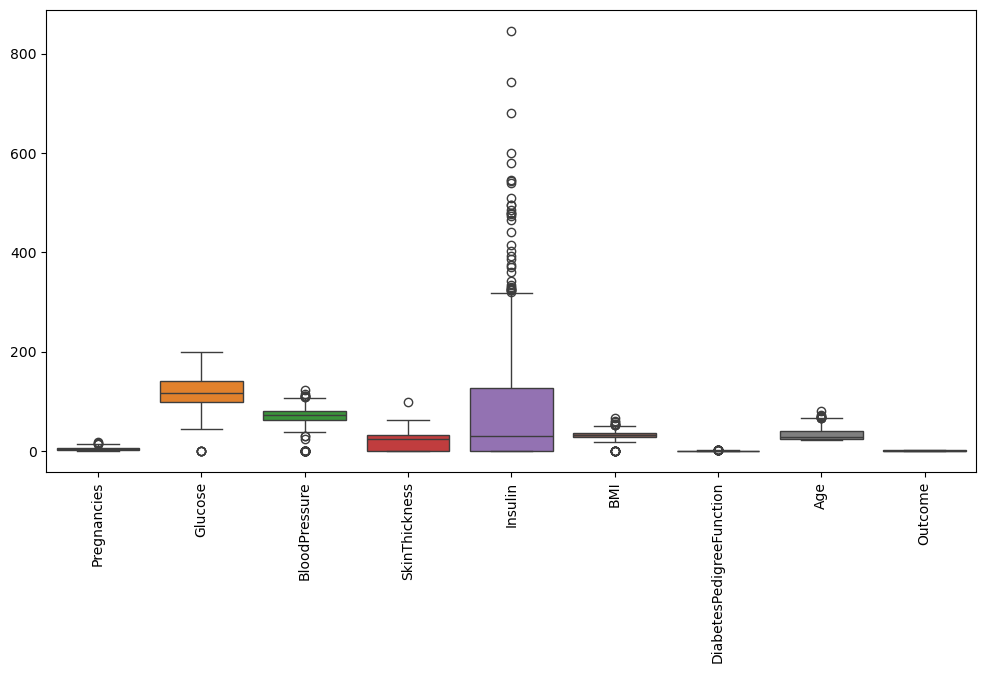

In [8]:
### Outlier check
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [9]:
#### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

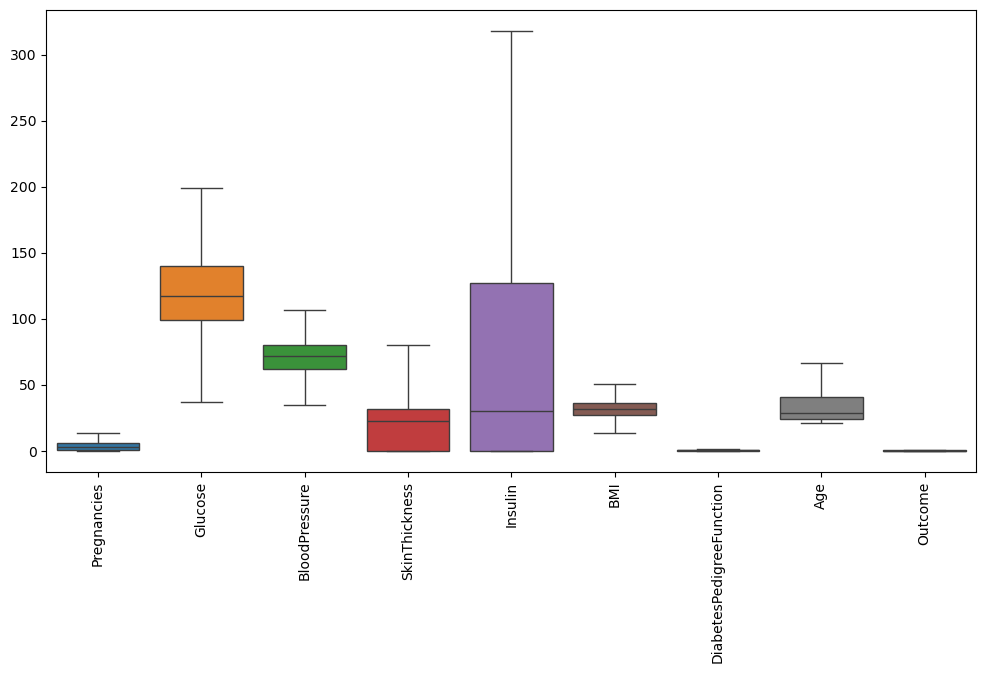

In [10]:
### Outlier check after capping
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

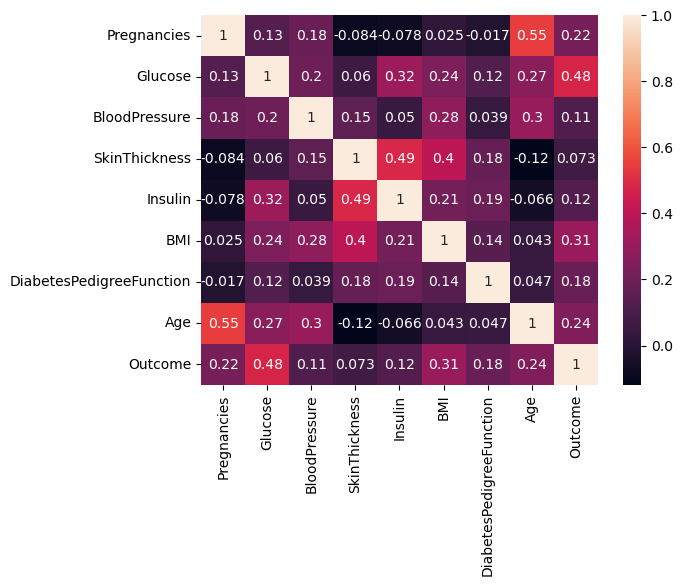

In [11]:
#### correlation
sns.heatmap(df.corr(),annot=True)
plt.show()

The  above correlation heatmap shows that most features have a weak to moderate correlation with the target variable (Outcome). Glucose has the strongest positive relationship with diabetes, making it the most important feature for prediction. BMI, Age, and Pregnancies also show a positive correlation with the target, indicating they contribute to diabetes prediction. Most other features have only a weak relationship with the target, and there are no extremely high correlations between the independent variables, suggesting that multicollinearity is not a major concern in this dataset.

In [12]:
target = df['Outcome']
features= df.drop('Outcome', axis=1)

#### 3. Model Building:

In [13]:
### Train-test_Split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [14]:
x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
660,10.0,162.0,84.0,0.0,0.0,27.7,0.182,54.0
69,4.0,146.0,85.0,27.0,100.0,28.9,0.189,27.0
85,2.0,110.0,74.0,29.0,125.0,32.4,0.698,27.0
219,5.0,112.0,66.0,0.0,0.0,37.8,0.261,41.0
712,10.0,129.0,62.0,36.0,0.0,41.2,0.441,38.0


In [15]:
### Scaling the Train test Data
std_sca=StandardScaler()

x_train_scaled = std_sca.fit_transform(x_train)
x_test_scaled = std_sca.transform(x_test)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=features.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=features.columns)


In [16]:
x_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1.896506,1.307446,0.949232,-1.267649,-0.770704,-0.593664,-0.944600,1.807381
1,0.075860,0.793186,1.019597,0.413020,0.303034,-0.426860,-0.920181,-0.541350
2,-0.531022,-0.363899,0.245588,0.537514,0.571468,0.059654,0.855435,-0.541350
3,0.379301,-0.299616,-0.317328,-1.267649,-0.770704,0.810275,-0.669013,0.676511
4,1.896506,0.246785,-0.598785,0.973243,-0.770704,1.282888,-0.041094,0.415540


In [17]:
x_test_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.834463,-1.360278,-0.739514,1.346725,-0.255310,1.602597,0.785666,-0.889310
1,-1.137904,-1.135289,-0.176599,0.724255,-0.770704,0.532267,-0.749247,-0.715330
2,0.379301,1.307446,2.356522,-1.267649,-0.770704,0.796375,-1.052742,1.633401
3,1.289624,-1.810256,0.104859,0.164032,-0.770704,0.004052,0.513568,0.763501
4,1.593065,0.053937,-0.035870,1.471219,0.238609,0.156957,-0.274820,0.589520


In [18]:
#### Model Training
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)

#### 4. Model Evaluation:

In [19]:
print('Accuracy:',accuracy_score(y_test,y_pred))

Accuracy: 0.7337662337662337


In [20]:
print('Precision:',precision_score(y_test, y_pred))

Precision: 0.6363636363636364


In [21]:
 print('Recall',recall_score(y_test, y_pred))

Recall 0.5283018867924528


In [22]:
print('f1_score',f1_score(y_test, y_pred))

f1_score 0.5773195876288659


In [23]:
sigmoid=log_model.predict_proba(x_test_scaled)[:,1] # if sigmoid value is >=0.5  then y_pred is 1
sigmoid

array([0.18856977, 0.06154767, 0.74879037, 0.10535014, 0.42379055,
       0.72417351, 0.96431232, 0.125094  , 0.91464196, 0.22932335,
       0.08751117, 0.88944585, 0.5918968 , 0.31401597, 0.74123421,
       0.28834687, 0.08001771, 0.24241486, 0.56170023, 0.14646336,
       0.24046296, 0.01130321, 0.56201002, 0.982054  , 0.26062076,
       0.85613133, 0.50171771, 0.31131527, 0.39814243, 0.58812918,
       0.04575168, 0.96656203, 0.16320322, 0.52266613, 0.21788735,
       0.33355674, 0.93368196, 0.02581383, 0.19134914, 0.29059619,
       0.33263806, 0.84005308, 0.43830992, 0.08914256, 0.26223742,
       0.93303607, 0.08807158, 0.22351416, 0.9047949 , 0.8927779 ,
       0.0961068 , 0.04139333, 0.32986772, 0.78553706, 0.77292954,
       0.90568296, 0.10397683, 0.05851452, 0.82259607, 0.09380556,
       0.16966608, 0.15271932, 0.30898016, 0.32154223, 0.40321852,
       0.26824808, 0.16476826, 0.02425484, 0.2133538 , 0.02661201,
       0.01733699, 0.6949126 , 0.10157956, 0.24081234, 0.15752

In [24]:
auc_score = roc_auc_score(y_test,sigmoid)
print('ROC-AUC Score:',auc_score)

ROC-AUC Score: 0.7788156174107976


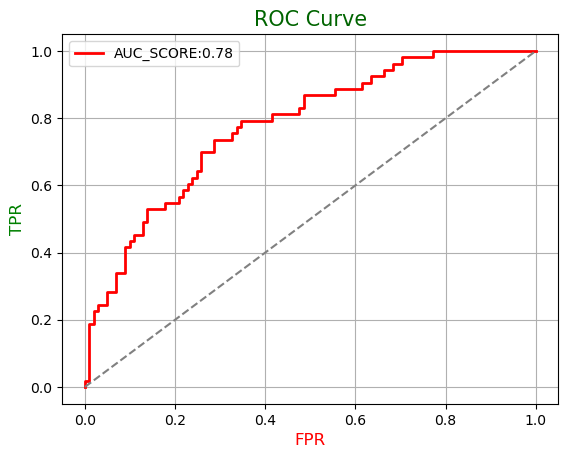

In [25]:
fpr,tpr,thr = roc_curve(y_test,sigmoid) ### False Positive Rate, True Positive Rate, Threshold
plt.plot(fpr,tpr,lw=2,color='red', label=f'AUC_SCORE:{auc_score:.2f}')
plt.plot([0,1],linestyle='--',color='grey')
plt.xlabel('FPR',color='red',size=12)
plt.ylabel('TPR',color='green',size=12)
plt.title('ROC Curve',color='darkgreen', size=15)
plt.grid()
plt.legend()
plt.show()

The ROC curve lies above the diagonal reference line with an AUC score of 0.78, indicating that the Logistic Regression model has a good ability to distinguish between diabetic and non-diabetic patients. This shows that the model performs better than random guessing and provides reliable predictions.

#### 5. Interpretation:

In [26]:
coef_df = pd.DataFrame({
    "Feature": features.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,Glucose,1.175736
5,BMI,0.736791
6,DiabetesPedigreeFunction,0.451576
0,Pregnancies,0.348317
7,Age,0.230889
4,Insulin,-0.081326
3,SkinThickness,-0.092080
2,BloodPressure,-0.144935


Glucose is the most significant predictor of diabetes, as it has the highest positive coefficient (1.1757). This indicates that higher glucose levels greatly increase the probability of diabetes. BMI, DiabetesPedigreeFunction, Pregnancies, and Age also have positive coefficients, suggesting that increases in these features are associated with a higher likelihood of diabetes. Insulin, SkinThickness, and BloodPressure have small negative coefficients, indicating a weak negative relationship with the target variable in this logistic regression model.

### Significance of Features

* **Glucose** is the most significant feature in predicting diabetes, as it has the highest positive coefficient (1.1757).
* **BMI** is the second most important feature. A higher BMI increases the likelihood of diabetes.
* **DiabetesPedigreeFunction** has a positive influence, indicating that a family history of diabetes increases the risk.
* **Pregnancies** positively contribute to diabetes prediction, suggesting that a higher number of pregnancies is associated with a greater risk.
* **Age** also has a positive effect, indicating that older individuals are more likely to develop diabetes.
* **Insulin**, **SkinThickness**, and **BloodPressure** have small negative coefficients, indicating that they have a relatively weaker influence on the prediction compared to the other features.
* Overall, **Glucose** and **BMI** are the most influential features, while **Insulin**, **SkinThickness**, and **BloodPressure** contribute less to the model's prediction.


#### 6. Deployment with Streamlit:

In [27]:
import pickle

pickle.dump(log_model, open("logistic_model.pkl", "wb"))

In [28]:
pickle.dump(std_sca, open("Scaler.pkl", "wb"))

#### Interview Questions:

##### 1. What is the difference between Precision and Recall?

**Precision:**

* Precision tells us how many of the predicted positive cases are actually positive.
* It focuses on reducing false positive predictions.

**Recall:**

* Recall tells us how many of the actual positive cases were correctly identified by the model.
* It focuses on reducing false negative predictions.

##### 2. What is Cross-Validation, and why is it important in binary classification?

Cross-validation is a method used to check how well a machine learning model performs. The dataset is divided into several parts. The model is trained on some parts and tested on the remaining part. This process is repeated until every part has been used for testing.

Why is it important?

* It gives a more reliable evaluation of the model.
* It helps reduce overfitting.
* It makes better use of the available data.
* It helps us understand how the model is likely to perform on new data.